# 1. Introduction

This notebook starts the baseline modeling phase for the CSIRO Image2Biomass competition. It is intentionally practical: establish reliable validation, compare simple baselines, train a metadata + image-feature model, inspect errors, and write a Kaggle-ready `submission.csv`.

The notebook expects the competition input at `/kaggle/input/competitions/csiro-biomass` and writes outputs to `/kaggle/working`.

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageStat
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)

PALETTE_NAME = 'viridis'
sns.set_theme(style='whitegrid', palette=PALETTE_NAME, rc={
    'figure.figsize': (11, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

DATA_DIR = Path('/kaggle/input/competitions/csiro-biomass')
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_ORDER = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
TARGET_WEIGHTS = {
    'Dry_Green_g': 0.1,
    'Dry_Dead_g': 0.1,
    'Dry_Clover_g': 0.1,
    'GDM_g': 0.2,
    'Dry_Total_g': 0.5,
}
TARGET_PALETTE = dict(zip(TARGET_ORDER, sns.color_palette(PALETTE_NAME, n_colors=len(TARGET_ORDER))))

if not DATA_DIR.exists():
    raise FileNotFoundError(f'Expected Kaggle input at {DATA_DIR}')

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Data directory: /kaggle/input/competitions/csiro-biomass
Output directory: /kaggle/working


# 2. Load Data And EDA Outputs

## 2.1 Competition Files

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f'train: {train.shape} | train images: {train.image_path.nunique():,}')
print(f'test: {test.shape} | test images: {test.image_path.nunique():,}')
print(f'sample_submission: {sample_submission.shape}')
display(train.head())
display(test.head())

train: (1785, 9) | train images: 357
test: (5, 3) | test images: 1
sample_submission: (5, 2)


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


## 2.2 Optional EDA Output Review

If you upload prior EDA artifacts into `/kaggle/working` or attach them as notebook outputs, this cell reviews them before training.

In [3]:
eda_paths = {
    'insights': OUTPUT_DIR / 'eda_insights.csv',
    'segment_error': OUTPUT_DIR / 'eda_segment_error.csv',
    'outliers': OUTPUT_DIR / 'eda_outlier_review.csv',
}

for name, path in eda_paths.items():
    if path.exists():
        print(f'Found {name}: {path}')
        df = pd.read_csv(path)
        display(df.head(12))
    else:
        print(f'Missing {name}: {path}')

Missing insights: /kaggle/working/eda_insights.csv
Missing segment_error: /kaggle/working/eda_segment_error.csv
Missing outliers: /kaggle/working/eda_outlier_review.csv


# 3. Metric And Validation

## 3.1 Weighted R2

In [4]:
def weighted_r2_score(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weighted_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * np.square(y_true - y_pred))
    ss_tot = np.sum(weights * np.square(y_true - weighted_mean))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

metric_view = pd.DataFrame({
    'target_name': TARGET_ORDER,
    'row_weight': [TARGET_WEIGHTS[t] for t in TARGET_ORDER],
})
metric_view['train_rows'] = metric_view['target_name'].map(train['target_name'].value_counts())
metric_view['effective_weight'] = metric_view['row_weight'] * metric_view['train_rows']
metric_view['effective_weight_share'] = metric_view['effective_weight'] / metric_view['effective_weight'].sum()
display(metric_view)

,target_name,row_weight,train_rows,effective_weight,effective_weight_share
0,Dry_Green_g,0.1,357,35.7,0.1
1,Dry_Dead_g,0.1,357,35.7,0.1
2,Dry_Clover_g,0.1,357,35.7,0.1
3,GDM_g,0.2,357,71.4,0.2
4,Dry_Total_g,0.5,357,178.5,0.5


## 3.2 Fold Strategy

Use `GroupKFold` by `image_path` so rows from the same image never appear in both train and validation folds.

In [5]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)
fold_map = {}
image_paths = train['image_path'].drop_duplicates().reset_index(drop=True)
for fold, (_, val_idx) in enumerate(gkf.split(image_paths, groups=image_paths), start=1):
    for image_path in image_paths.iloc[val_idx]:
        fold_map[image_path] = fold
train['fold'] = train['image_path'].map(fold_map)

display(pd.crosstab(train['fold'], train['target_name']))

target_name,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
fold,,,,,
1,72,72,72,72,72
2,72,72,72,72,72
3,71,71,71,71,71
4,71,71,71,71,71
5,71,71,71,71,71


# 4. Feature Engineering

## 4.1 Image-Level Target Frame

In [6]:
meta_cols = ['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'fold']
image_meta = train[meta_cols].drop_duplicates('image_path').copy()
image_targets = train.pivot_table(index='image_path', columns='target_name', values='target', aggfunc='first').reset_index()
image_train = image_meta.merge(image_targets, on='image_path', how='left')

test_image = test.drop_duplicates('image_path').copy()
for col in ['Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']:
    if col not in test_image.columns:
        test_image[col] = np.nan

print(image_train.shape, test_image.shape)
display(image_train.head())

(357, 12) (1, 8)


,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,fold,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,1,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,5,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,4,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,3,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,2,0.4343,23.2239,10.5261,34.1844,10.9605


## 4.2 Metadata Features

In [7]:
def add_metadata_features(df):
    out = df.copy()
    dates = pd.to_datetime(out.get('Sampling_Date'), errors='coerce')
    out['sample_month'] = dates.dt.month
    out['sample_dayofyear'] = dates.dt.dayofyear
    out['sample_year'] = dates.dt.year
    species = out['Species'].fillna('Unknown').astype(str)
    out['primary_species'] = species.str.split('_').str[0]
    out['species_count'] = np.where(species.eq('Unknown'), 0, species.str.count('_') + 1)
    out['ndvi_x_height'] = out['Pre_GSHH_NDVI'] * out['Height_Ave_cm']
    out['height_log1p'] = np.log1p(out['Height_Ave_cm'].clip(lower=0))
    return out

image_train = add_metadata_features(image_train)
test_image = add_metadata_features(test_image)

## 4.3 Simple Image Features

The EDA notebook may already have exported these. If not, this cell extracts them from images.

In [8]:
def extract_image_features(df, cache_name):
    cache_path = OUTPUT_DIR / cache_name
    if cache_path.exists():
        print(f'Loading cached features: {cache_path}')
        return pd.read_csv(cache_path)

    rows = []
    for rel_path in tqdm(df['image_path'].drop_duplicates().tolist(), desc=cache_name):
        path = DATA_DIR / rel_path
        row = {'image_path': rel_path}
        try:
            img = Image.open(path).convert('RGB')
            row['width'], row['height'] = img.size
            small = img.resize((256, 256))
            arr = np.asarray(small, dtype=np.float32) / 255.0
            stat = ImageStat.Stat(small)
            for idx, ch in enumerate(['r', 'g', 'b']):
                row[f'{ch}_mean'] = stat.mean[idx] / 255.0
                row[f'{ch}_std'] = stat.stddev[idx] / 255.0
                row[f'{ch}_p10'] = np.quantile(arr[:, :, idx], 0.10)
                row[f'{ch}_p50'] = np.quantile(arr[:, :, idx], 0.50)
                row[f'{ch}_p90'] = np.quantile(arr[:, :, idx], 0.90)
            red, green, blue = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
            row['brightness'] = arr.mean()
            row['contrast'] = arr.std()
            row['excess_green'] = np.mean(2 * green - red - blue)
            row['green_red_ratio'] = np.mean(green / (red + 1e-4))
            row['visible_ndvi_proxy'] = np.mean((green - red) / (green + red + 1e-4))
        except Exception as exc:
            row['image_error'] = str(exc)
        rows.append(row)

    features = pd.DataFrame(rows)
    features.to_csv(cache_path, index=False)
    print(f'Wrote {cache_path}')
    return features

train_img = extract_image_features(image_train, 'train_image_features.csv')
test_img = extract_image_features(test_image, 'test_image_features.csv')

image_train = image_train.merge(train_img, on='image_path', how='left')
test_image = test_image.merge(test_img, on='image_path', how='left')

train_image_features.csv:   0%|          | 0/357 [00:00<?, ?it/s]

Wrote /kaggle/working/train_image_features.csv


test_image_features.csv:   0%|          | 0/1 [00:00<?, ?it/s]

Wrote /kaggle/working/test_image_features.csv


## 4.4 Long Format Modeling Table

In [9]:
def to_long(df, include_targets=True):
    repeated = []
    for target_name in TARGET_ORDER:
        tmp = df.copy()
        tmp['target_name'] = target_name
        tmp['target_weight'] = TARGET_WEIGHTS[target_name]
        if include_targets:
            tmp['target'] = tmp[target_name]
        repeated.append(tmp)
    return pd.concat(repeated, ignore_index=True)

train_long = to_long(image_train, include_targets=True)
test_long = test.merge(test_image.drop(columns=[c for c in ['sample_id', 'target_name'] if c in test_image.columns]), on='image_path', how='left')
test_long['target_weight'] = test_long['target_name'].map(TARGET_WEIGHTS)

feature_cols = [
    'target_name', 'State', 'Species', 'primary_species', 'species_count',
    'Pre_GSHH_NDVI', 'Height_Ave_cm', 'ndvi_x_height', 'height_log1p',
    'sample_month', 'sample_dayofyear', 'sample_year',
    'width', 'height', 'brightness', 'contrast', 'excess_green', 'green_red_ratio', 'visible_ndvi_proxy',
    'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std',
    'r_p10', 'r_p50', 'r_p90', 'g_p10', 'g_p50', 'g_p90', 'b_p10', 'b_p50', 'b_p90',
]
feature_cols = [c for c in feature_cols if c in train_long.columns]
cat_cols = [c for c in ['target_name', 'State', 'Species', 'primary_species'] if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f'{len(feature_cols)} features')
print('categorical:', cat_cols)
print('numeric:', len(num_cols))

34 features
categorical: ['target_name', 'State', 'Species', 'primary_species']
numeric: 30


# 5. Baseline Experiments

## 5.1 Model Definitions

In [10]:
def make_preprocess(scale_numeric=False):
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=3)),
        ]), cat_cols),
    ])

models = {
    'dummy_median': Pipeline([
        ('preprocess', make_preprocess()),
        ('model', DummyRegressor(strategy='median')),
    ]),
    'ridge_log': Pipeline([
        ('preprocess', make_preprocess(scale_numeric=True)),
        ('model', Ridge(alpha=10.0, random_state=42)),
    ]),
    'hgb': Pipeline([
        ('preprocess', make_preprocess()),
        ('model', HistGradientBoostingRegressor(
            max_iter=450,
            learning_rate=0.045,
            l2_regularization=0.05,
            max_leaf_nodes=31,
            random_state=42,
        )),
    ]),
    'extra_trees': Pipeline([
        ('preprocess', make_preprocess()),
        ('model', ExtraTreesRegressor(
            n_estimators=350,
            min_samples_leaf=3,
            max_features=0.75,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

## 5.2 Cross-Validation Runner

In [11]:
def cross_validate_model(name, estimator, use_log_target=False):
    parts = []
    for fold in sorted(train_long['fold'].unique()):
        trn = train_long[train_long['fold'] != fold]
        val = train_long[train_long['fold'] == fold]
        model = clone(estimator)
        y_train = np.log1p(trn['target']) if use_log_target else trn['target']
        model.fit(trn[feature_cols], y_train)
        pred = model.predict(val[feature_cols])
        if use_log_target:
            pred = np.expm1(pred)
        pred = np.clip(pred, 0, None)
        keep_cols = [c for c in ['image_path', 'fold', 'State', 'primary_species', 'target_name', 'target', 'target_weight'] if c in val.columns]
        fold_df = val[keep_cols].copy()
        fold_df['prediction'] = pred
        fold_df['model'] = name
        parts.append(fold_df)
    out = pd.concat(parts, ignore_index=True)
    out['error'] = out['prediction'] - out['target']
    out['abs_error'] = out['error'].abs()
    return out

all_oof = []
for name, model in models.items():
    use_log = name in ['ridge_log']
    print(f'Running {name}')
    all_oof.append(cross_validate_model(name, model, use_log_target=use_log))

oof = pd.concat(all_oof, ignore_index=True)
summary = (
    oof.groupby('model')
    .apply(lambda x: pd.Series({
        'weighted_r2': weighted_r2_score(x['target'], x['prediction'], x['target_weight']),
        'mae': mean_absolute_error(x['target'], x['prediction']),
        'bias': np.mean(x['error']),
    }))
    .sort_values('weighted_r2', ascending=False)
)
display(summary)
summary.to_csv(OUTPUT_DIR / 'baseline_cv_summary.csv')
print(f'Wrote {OUTPUT_DIR / "baseline_cv_summary.csv"}')

Running dummy_median
Running ridge_log
Running hgb
Running extra_trees


,weighted_r2,mae,bias
model,,,
extra_trees,0.807153,6.816718,0.144134
hgb,0.783777,7.550568,0.283828
ridge_log,0.610028,10.816347,-5.608553
dummy_median,-0.304126,18.685897,-6.497037


Wrote /kaggle/working/baseline_cv_summary.csv


## 5.3 Per-Target Diagnostics

Best model: extra_trees


,weighted_r2,mae,bias,target_mean
target_name,,,,
Dry_Green_g,0.7799,7.1336,0.2136,26.6247
Dry_Dead_g,0.4940,5.6402,0.1066,12.0445
Dry_Clover_g,0.5954,3.9746,0.1419,6.6497
GDM_g,0.8034,7.2418,0.1389,33.2744
Dry_Total_g,0.7380,10.0933,0.1197,45.3181


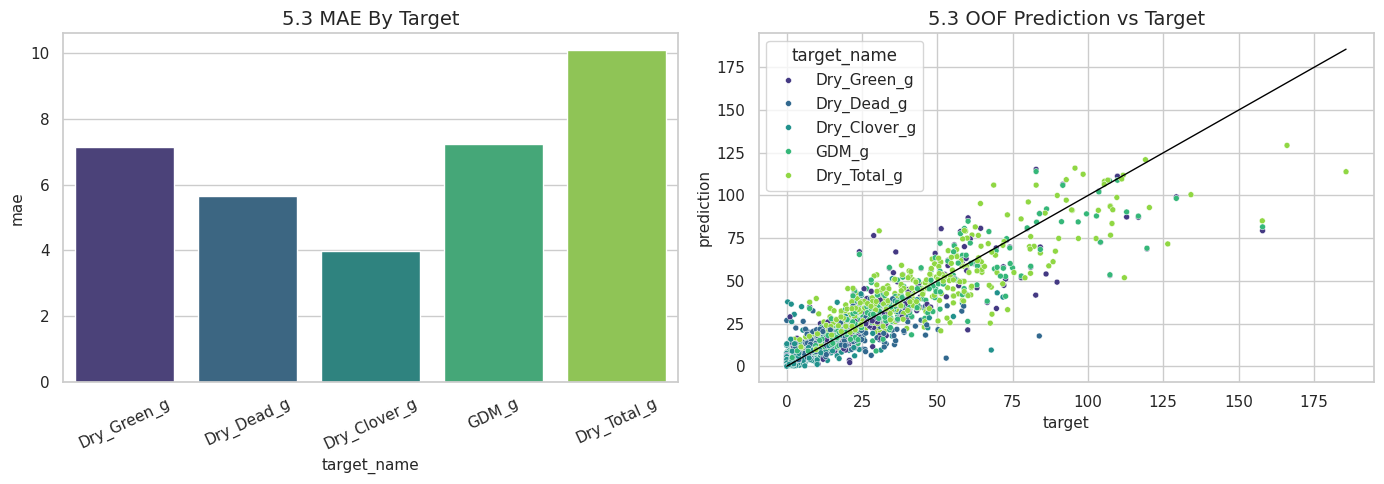

In [12]:
best_model_name = summary.index[0]
best_oof = oof[oof['model'] == best_model_name].copy()
print(f'Best model: {best_model_name}')

per_target = (
    best_oof.groupby('target_name')
    .apply(lambda x: pd.Series({
        'weighted_r2': weighted_r2_score(x['target'], x['prediction'], x['target_weight']),
        'mae': mean_absolute_error(x['target'], x['prediction']),
        'bias': np.mean(x['error']),
        'target_mean': x['target'].mean(),
    }))
    .reindex(TARGET_ORDER)
)
display(per_target.round(4))
per_target.to_csv(OUTPUT_DIR / 'baseline_per_target.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=per_target.reset_index(names='target_name'), x='target_name', y='mae', hue='target_name', palette=TARGET_PALETTE, legend=False, ax=axes[0])
axes[0].set_title('5.3 MAE By Target')
axes[0].tick_params(axis='x', rotation=25)

sns.scatterplot(data=best_oof, x='target', y='prediction', hue='target_name', palette=TARGET_PALETTE, s=18, ax=axes[1])
limit = max(best_oof['target'].max(), best_oof['prediction'].max())
axes[1].plot([0, limit], [0, limit], color='black', linewidth=1)
axes[1].set_title('5.3 OOF Prediction vs Target')
plt.tight_layout()
plt.show()

## 5.4 Target Relationship Check

EDA showed that `Dry_Total_g` exactly equals `Dry_Green_g + Dry_Dead_g + Dry_Clover_g` in train. This cell checks whether enforcing that relationship improves validation before applying it to the submission.

In [ ]:
def apply_total_constraint(long_df, pred_col='prediction'):
    wide = long_df.pivot_table(index='image_path', columns='target_name', values=pred_col, aggfunc='first')
    required = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g']
    if not all(c in wide.columns for c in required):
        return long_df.copy()
    constrained_total = wide[required].sum(axis=1)
    out = long_df.copy()
    mask = out['target_name'].eq('Dry_Total_g')
    out.loc[mask, pred_col] = out.loc[mask, 'image_path'].map(constrained_total)
    out['error'] = out[pred_col] - out['target']
    out['abs_error'] = out['error'].abs()
    return out

best_oof_constrained = apply_total_constraint(best_oof)
raw_score = weighted_r2_score(best_oof['target'], best_oof['prediction'], best_oof['target_weight'])
constrained_score = weighted_r2_score(best_oof_constrained['target'], best_oof_constrained['prediction'], best_oof_constrained['target_weight'])
USE_TOTAL_CONSTRAINT = constrained_score >= raw_score

print(f'Raw weighted R2:         {raw_score:.5f}')
print(f'Constrained weighted R2: {constrained_score:.5f}')
print(f'Use total constraint for submission: {USE_TOTAL_CONSTRAINT}')

## 5.5 Segment Diagnostics

In [13]:
segment_cols = [c for c in ['target_name', 'State'] if c in best_oof.columns]
segment_error = (
    best_oof.groupby(segment_cols)
    .agg(rows=('target', 'size'), mae=('abs_error', 'mean'), bias=('error', 'mean'), target_mean=('target', 'mean'))
    .reset_index()
    .sort_values('mae', ascending=False)
)
display(segment_error.head(20).round(3))
segment_error.to_csv(OUTPUT_DIR / 'baseline_segment_error.csv', index=False)
print(f'Wrote {OUTPUT_DIR / "baseline_segment_error.csv"}')

,target_name,State,rows,mae,bias,target_mean
12,Dry_Total_g,NSW,75,16.613,-0.183,70.897
16,GDM_g,NSW,75,13.707,0.067,56.694
8,Dry_Green_g,NSW,75,13.586,-0.061,56.559
3,Dry_Clover_g,WA,32,10.276,-1.456,22.088
13,Dry_Total_g,Tas,138,9.312,-0.297,36.798
15,Dry_Total_g,WA,32,8.215,-0.130,31.388
4,Dry_Dead_g,NSW,75,8.072,0.316,14.203
19,GDM_g,WA,32,7.388,-0.624,31.388
14,Dry_Total_g,Vic,112,7.227,0.908,42.667
5,Dry_Dead_g,Tas,138,6.551,-0.237,15.231


Wrote /kaggle/working/baseline_segment_error.csv


# 6. Deep-Dive Diagnostics

## 6.1 High-Biomass NSW Image Inspection

EDA showed NSW dominates the hardest high-biomass errors. This section lists and displays the largest NSW biomass cases so we can check whether the model is missing dense pasture, lighting, framing, or species patterns.

In [ ]:
high_nsw = (
    image_train[image_train['State'].eq('NSW')]
    .sort_values('Dry_Total_g', ascending=False)
    .head(16)
    .copy()
)
review_cols = ['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
review_cols = [c for c in review_cols if c in high_nsw.columns]
display(high_nsw[review_cols])
high_nsw[review_cols].to_csv(OUTPUT_DIR / 'high_biomass_nsw_review.csv', index=False)

cols = 4
rows = math.ceil(len(high_nsw) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 3.8 * rows))
axes = np.array(axes).reshape(-1)
for ax, (_, row) in zip(axes, high_nsw.iterrows()):
    img = Image.open(DATA_DIR / row['image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(
        f"{Path(row['image_path']).name}\nTotal={row['Dry_Total_g']:.1f} | Green={row['Dry_Green_g']:.1f} | Dead={row['Dry_Dead_g']:.1f}",
        fontsize=9,
    )
    ax.axis('off')
for ax in axes[len(high_nsw):]:
    ax.axis('off')
fig.suptitle('6.1 Highest Dry_Total_g NSW Training Images', y=1.01)
plt.tight_layout()
plt.show()
print(f'Wrote {OUTPUT_DIR / "high_biomass_nsw_review.csv"}')

## 6.2 Image-Only vs Metadata-Assisted Validation

This compares feature families under the same grouped CV. `test_available` is the submission-safe setting. Metadata-assisted variants are diagnostic/oracle views unless those fields are also present in hidden test.

In [ ]:
def make_preprocess_for(cols, scale_numeric=False):
    local_cat = [c for c in ['target_name', 'State', 'Species', 'primary_species'] if c in cols]
    local_num = [c for c in cols if c not in local_cat]
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), local_num),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=3)),
        ]), local_cat),
    ])

image_feature_base = [
    'width', 'height', 'brightness', 'contrast', 'excess_green', 'green_red_ratio', 'visible_ndvi_proxy',
    'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std',
    'r_p10', 'r_p50', 'r_p90', 'g_p10', 'g_p50', 'g_p90', 'b_p10', 'b_p50', 'b_p90',
]
metadata_feature_base = [
    'State', 'Species', 'primary_species', 'species_count', 'Pre_GSHH_NDVI', 'Height_Ave_cm',
    'ndvi_x_height', 'height_log1p', 'sample_month', 'sample_dayofyear', 'sample_year',
]
image_cols = ['target_name'] + [c for c in image_feature_base if c in train_long.columns]
metadata_cols = ['target_name'] + [c for c in metadata_feature_base if c in train_long.columns]
image_metadata_cols = list(dict.fromkeys(image_cols + metadata_cols))

feature_sets = {
    'test_available': feature_cols,
    'image_only': image_cols,
    'metadata_only_oracle': metadata_cols,
    'image_plus_metadata_oracle': image_metadata_cols,
}

feature_set_parts = []
for set_name, cols in feature_sets.items():
    cols = [c for c in cols if c in train_long.columns]
    estimator = Pipeline([
        ('preprocess', make_preprocess_for(cols)),
        ('model', ExtraTreesRegressor(
            n_estimators=250,
            min_samples_leaf=3,
            max_features=0.75,
            random_state=2026,
            n_jobs=-1,
        )),
    ])
    print(f'Running feature set: {set_name} ({len(cols)} features)')
    parts = []
    for fold in sorted(train_long['fold'].unique()):
        trn = train_long[train_long['fold'] != fold]
        val = train_long[train_long['fold'] == fold]
        model = clone(estimator)
        model = fit_with_weights(model, trn[cols], trn['target'], trn['target_weight'])
        pred = np.clip(model.predict(val[cols]), 0, None)
        tmp = val[['image_path', 'fold', 'target_name', 'target', 'target_weight']].copy()
        tmp['prediction'] = pred
        tmp['feature_set'] = set_name
        parts.append(tmp)
    fs_oof = pd.concat(parts, ignore_index=True)
    fs_oof['error'] = fs_oof['prediction'] - fs_oof['target']
    fs_oof['abs_error'] = fs_oof['error'].abs()
    feature_set_parts.append(fs_oof)

feature_set_oof = pd.concat(feature_set_parts, ignore_index=True)
feature_set_summary = (
    feature_set_oof.groupby('feature_set')
    .apply(lambda x: pd.Series({
        'weighted_r2': weighted_r2_score(x['target'], x['prediction'], x['target_weight']),
        'mae': mean_absolute_error(x['target'], x['prediction']),
        'bias': np.mean(x['error']),
    }))
    .sort_values('weighted_r2', ascending=False)
)
display(feature_set_summary)
feature_set_summary.to_csv(OUTPUT_DIR / 'feature_set_cv_summary.csv')
print(f'Wrote {OUTPUT_DIR / "feature_set_cv_summary.csv"}')

## 6.3 Zero-Inflated Clover And Dead Matter

`Dry_Clover_g` and `Dry_Dead_g` contain many true zeros. This tests a two-stage approach: first predict whether biomass is nonzero, then predict amount conditional on being positive.

In [ ]:
def make_zero_stage_models(cols, seed=2026):
    classifier = Pipeline([
        ('preprocess', make_preprocess_for(cols)),
        ('model', ExtraTreesClassifier(
            n_estimators=250,
            min_samples_leaf=3,
            max_features=0.75,
            random_state=seed,
            n_jobs=-1,
            class_weight='balanced',
        )),
    ])
    regressor = Pipeline([
        ('preprocess', make_preprocess_for(cols)),
        ('model', ExtraTreesRegressor(
            n_estimators=250,
            min_samples_leaf=3,
            max_features=0.75,
            random_state=seed,
            n_jobs=-1,
        )),
    ])
    return classifier, regressor

zero_targets = ['Dry_Clover_g', 'Dry_Dead_g']
zero_cols = [c for c in feature_cols if c != 'target_name']
zero_parts = []
zero_summary_rows = []

for target_name in zero_targets:
    target_df = image_train.copy()
    y = target_df[target_name].astype(float)
    print(f'Running two-stage zero model for {target_name}: zero share={(y.eq(0).mean()):.1%}')
    preds = np.zeros(len(target_df))
    prob_nonzero = np.zeros(len(target_df))
    for fold in sorted(target_df['fold'].unique()):
        trn_idx = target_df['fold'] != fold
        val_idx = target_df['fold'] == fold
        trn = target_df.loc[trn_idx]
        val = target_df.loc[val_idx]
        y_trn = y.loc[trn_idx]
        clf, reg = make_zero_stage_models(zero_cols, seed=3000 + int(fold))
        clf.fit(trn[zero_cols], y_trn.gt(0).astype(int))
        proba = clf.predict_proba(val[zero_cols])
        positive_class_index = list(clf.named_steps['model'].classes_).index(1) if 1 in clf.named_steps['model'].classes_ else 0
        p_nonzero = proba[:, positive_class_index]
        pos_mask = y_trn.gt(0)
        if pos_mask.sum() >= 8:
            reg.fit(trn.loc[pos_mask, zero_cols], np.log1p(y_trn.loc[pos_mask]))
            amount = np.expm1(reg.predict(val[zero_cols]))
        else:
            amount = np.repeat(y_trn[y_trn.gt(0)].median() if y_trn.gt(0).any() else 0, len(val))
        preds[val_idx] = np.clip(p_nonzero * amount, 0, None)
        prob_nonzero[val_idx] = p_nonzero
    tmp = target_df[['image_path', 'fold', 'State', 'primary_species']].copy()
    tmp['target_name'] = target_name
    tmp['target'] = y
    tmp['target_weight'] = TARGET_WEIGHTS[target_name]
    tmp['prediction'] = preds
    tmp['prob_nonzero'] = prob_nonzero
    tmp['error'] = tmp['prediction'] - tmp['target']
    tmp['abs_error'] = tmp['error'].abs()
    zero_parts.append(tmp)

    one_stage = best_oof[best_oof['target_name'].eq(target_name)]
    zero_summary_rows.append({
        'target_name': target_name,
        'zero_share': y.eq(0).mean(),
        'one_stage_mae': mean_absolute_error(one_stage['target'], one_stage['prediction']),
        'two_stage_mae': mean_absolute_error(tmp['target'], tmp['prediction']),
        'one_stage_weighted_r2': weighted_r2_score(one_stage['target'], one_stage['prediction'], one_stage['target_weight']),
        'two_stage_weighted_r2': weighted_r2_score(tmp['target'], tmp['prediction'], tmp['target_weight']),
        'two_stage_bias': tmp['error'].mean(),
    })

zero_oof = pd.concat(zero_parts, ignore_index=True)
zero_summary = pd.DataFrame(zero_summary_rows)
display(zero_summary.round(4))
zero_summary.to_csv(OUTPUT_DIR / 'zero_inflation_summary.csv', index=False)
zero_oof.to_csv(OUTPUT_DIR / 'zero_inflation_oof.csv', index=False)
print(f'Wrote {OUTPUT_DIR / "zero_inflation_summary.csv"}')
print(f'Wrote {OUTPUT_DIR / "zero_inflation_oof.csv"}')

# 7. Train Full Model And Create Submission

## 7.1 Fit Best Model

In [14]:
def fresh_model(name):
    if name == 'dummy_median':
        return Pipeline([('preprocess', make_preprocess()), ('model', DummyRegressor(strategy='median'))])
    if name == 'ridge_log':
        return Pipeline([('preprocess', make_preprocess(scale_numeric=True)), ('model', Ridge(alpha=10.0, random_state=42))])
    if name == 'extra_trees':
        return Pipeline([('preprocess', make_preprocess()), ('model', ExtraTreesRegressor(n_estimators=350, min_samples_leaf=3, max_features=0.75, random_state=42, n_jobs=-1))])
    return Pipeline([('preprocess', make_preprocess()), ('model', HistGradientBoostingRegressor(max_iter=450, learning_rate=0.045, l2_regularization=0.05, max_leaf_nodes=31, random_state=42))])

final_model = fresh_model(best_model_name)
use_log = best_model_name == 'ridge_log'
y_full = np.log1p(train_long['target']) if use_log else train_long['target']
final_model.fit(train_long[feature_cols], y_full)
print(f'Fitted final model: {best_model_name}')

Fitted final model: extra_trees


## 7.2 Write Submission

In [15]:
raw_pred = final_model.predict(test_long[feature_cols])
if use_log:
    raw_pred = np.expm1(raw_pred)
raw_pred = np.clip(raw_pred, 0, None)

pred_df = test_long[['sample_id']].copy()
pred_df['target'] = raw_pred

if 'USE_TOTAL_CONSTRAINT' in globals() and USE_TOTAL_CONSTRAINT:
    wide_pred = test_long[['image_path', 'target_name']].copy()
    wide_pred['target'] = raw_pred
    wide_pred = wide_pred.pivot_table(index='image_path', columns='target_name', values='target', aggfunc='first')
    required = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g']
    if all(c in wide_pred.columns for c in required):
        constrained_total = wide_pred[required].sum(axis=1)
        total_mask = test_long['target_name'].eq('Dry_Total_g')
        pred_df.loc[total_mask.values, 'target'] = test_long.loc[total_mask, 'image_path'].map(constrained_total).values

submission = sample_submission[['sample_id']].merge(pred_df, on='sample_id', how='left')

if submission['target'].isna().any():
    fallback = train.groupby('target_name')['target'].median()
    missing = submission['target'].isna()
    missing_targets = submission.loc[missing, ['sample_id']].merge(test[['sample_id', 'target_name']], on='sample_id', how='left')['target_name']
    submission.loc[missing, 'target'] = missing_targets.map(fallback).values

submission['target'] = submission['target'].clip(lower=0)
submission_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(submission_path, index=False)

display(submission.head(10))
print(submission.shape)
print(f'Wrote {submission_path}')

,sample_id,target
0,ID1001187975__Dry_Clover_g,1.272192
1,ID1001187975__Dry_Dead_g,24.022436
2,ID1001187975__Dry_Green_g,17.849335
3,ID1001187975__Dry_Total_g,43.759431
4,ID1001187975__GDM_g,17.385451


(5, 2)
Wrote /kaggle/working/submission.csv


# 8. Modeling Notes

Use this notebook as the first benchmark, not the final model. The next upgrades should be measured against `baseline_cv_summary.csv` using the same grouped validation:

- train target-specific models instead of one long-format model
- add pretrained CNN or ViT image embeddings
- blend metadata models with image models
- enforce biomass accounting relationships during post-processing only if validation improves
- add external weather or satellite features if allowed and reproducible in Kaggle